In [1]:
import numpy as np
import scipy as sp
import krylov as kr
import ham_generator as gen
import matplotlib.pyplot as plt
import networkx as nx

# Real triangle with initial superposition of two sites

$$\ket{\psi_0} = \text{cos}\left(\frac{\theta}{2}\right)\ket{0} + e^{i\varphi}\text{sin}\left(\frac{\theta}{2}\right)\ket{1} $$

$$\ket{\psi_0} = c_0(\theta,\varphi)\ket{E_0} + c_+(\theta,\varphi)\ket{E_+} $$

with: $$ c_0(\theta,\varphi) = \frac{1}{\sqrt{3}}\left (\text{cos}\left(\frac{\theta}{2}\right) + e^{i\varphi}\text{sin}\left(\frac{\theta}{2}\right)\right )  $$ ,

$$c_+(\theta,\varphi) = \sqrt{\frac{2}{3}}\sqrt{1+\text{cos}\left(\frac{\theta}{2}\right)\text{sin}\left(\frac{\theta}{2}\right)\left(\text{cos}(\varphi+2\pi/3)+\text{cos}(\varphi+4\pi/3)  \right)} $$

The only relevant Lanczos coefficients are $ a_0 $ and $ b_1 $, which evaluate to:

\begin{equation}
    a_0(\theta, \phi) = \text{sin}(\theta)\text{cos}(\varphi),
\end{equation}
and
\begin{equation}
    b_1(\theta, \phi) = \sqrt{|c_0|^2(2-a_0)^2+|c_+|^2(1+a_0)^2}
\end{equation}

The infinite time-averaged complexity is:
\begin{equation}
    \bar{C}(\theta, \phi) = \frac{1}{b_1^2}\left ( |c_0|^4(2-a_0)^2 + |c_+|^4(1+a_0)^2 \right)
\end{equation}

In [77]:
#definition of analytical solutions
#C0
def c_0(theta, phi):
    norm = 1./np.sqrt(3)
    c = np.cos(theta/2.)
    s = np.sin(theta/2.)
    phase = np.exp(phi*1.j)
    return norm*(c+phase*s)

#C+
def c_plus(theta, phi):
    norm = np.sqrt(2./3.)
    c = np.cos(theta/2.)
    s = np.sin(theta/2.)
    shift = 2.*np.pi/3.
    c1 = np.cos(phi+shift)
    c2 = np.cos(phi+2*shift)
    body = 1+c*s*(c1+c2)
    return norm*np.sqrt(body)

#a0
def a_0(theta, phi):
    s = np.sin(theta)
    c = np.cos(phi)
    return s*c

#b1
def b_1(theta, phi):
    first = (np.abs(c_0(theta, phi))*(2.-a_0(theta, phi)))**2
    second = (np.abs(c_plus(theta, phi))*(1.+a_0(theta, phi)))**2
    return np.sqrt(first+second)

#complexity
def c_bar(theta, phi):
    norm = 1./(b_1(theta,phi)**2)
    first = (np.abs(c_0(theta, phi))**4)*(2.-a_0(theta, phi))**2
    second = (np.abs(c_plus(theta, phi))**4)*(1.+a_0(theta, phi))**2
    return norm*(first+second)


In [60]:
n_thetas = 1000
n_phis = 1000

thetas = np.linspace(start=0.,stop=np.pi, num=n_thetas)
phis = np.linspace(start=0., stop=2*np.pi, num=n_phis)

#theta_phis = np.array([[(theta, phi) for phi in phis] for theta in thetas])

a_0s= np.array([[a_0(theta, phi) for theta in thetas] for phi in phis])
#print(a_0s[:,1])

## $a_0$ as a function of $\theta$ and $\phi$

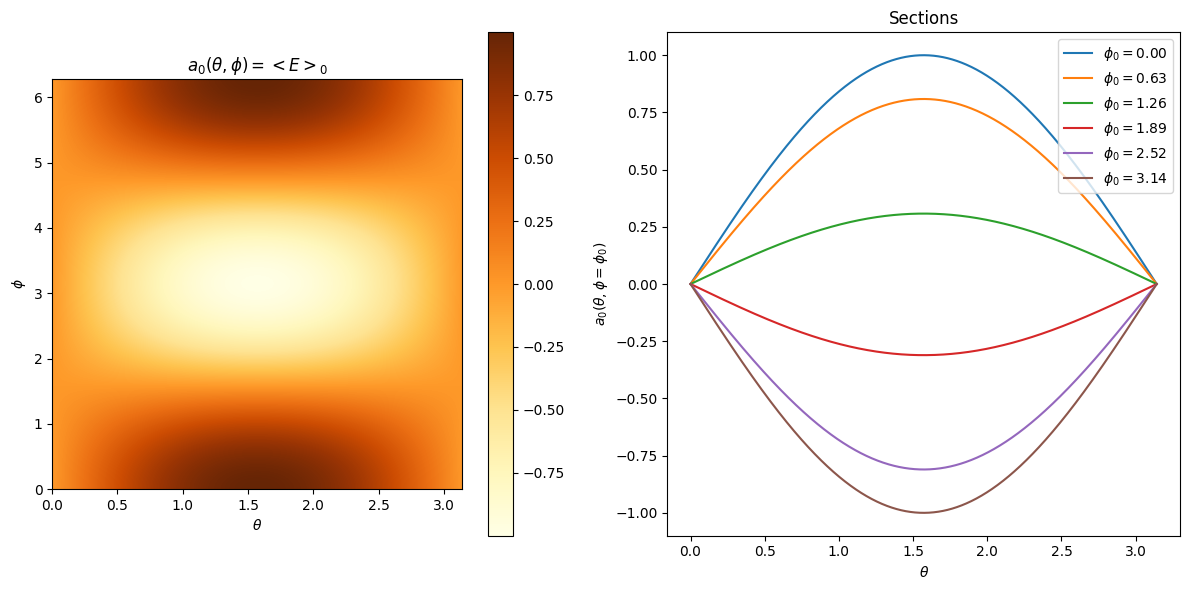

In [63]:
fig, axx = plt.subplots(1,2, figsize=(12,6), tight_layout=True)

Z = a_0s

im = axx[0].imshow(Z, extent=[thetas[0], thetas[-1], phis[0], phis[-1]], origin='lower', cmap='YlOrBr')
cbr = fig.colorbar(im, ax=axx[0])
axx[0].set_aspect(0.5)
axx[0].set_xlabel(r'$\theta$')
axx[0].set_ylabel(r'$\phi$')
axx[0].set_title(r'$a_0(\theta, \phi)= < E >_0$')

for i in range(6):
    axx[1].plot(thetas, a_0s[100*i,:], label=f"$\phi_0=${format(phis[100*i], '.2f')}")
axx[1].set_xlabel(r'$\theta$')
axx[1].set_ylabel(r'$a_0(\theta, \phi=\phi_0)$')
axx[1].set_title(r'Sections')
axx[1].legend()

plt.show()

## $\bar{C}$ as a function of $\theta$ and $\phi$

\begin{equation}
    \bar{C}(\theta, \phi) = \frac{1}{b_1^2}\left ( |c_0|^4(2-a_0)^2 + |c_+|^4(1+a_0)^2 \right)
\end{equation}

\begin{equation}
    a_0(\theta, \phi) = \text{sin}(\theta)\text{cos}(\varphi)
\end{equation}

In [65]:
n_thetas = 1000
n_phis = 1000

thetas = np.linspace(start=0.,stop=np.pi, num=n_thetas)
phis = np.linspace(start=0., stop=2*np.pi, num=n_phis)

#theta_phis = np.array([[(theta, phi) for phi in phis] for theta in thetas])

c_bars= np.array([[c_bar(theta, phi) for theta in thetas] for phi in phis])
#print(a_0s[:,1])

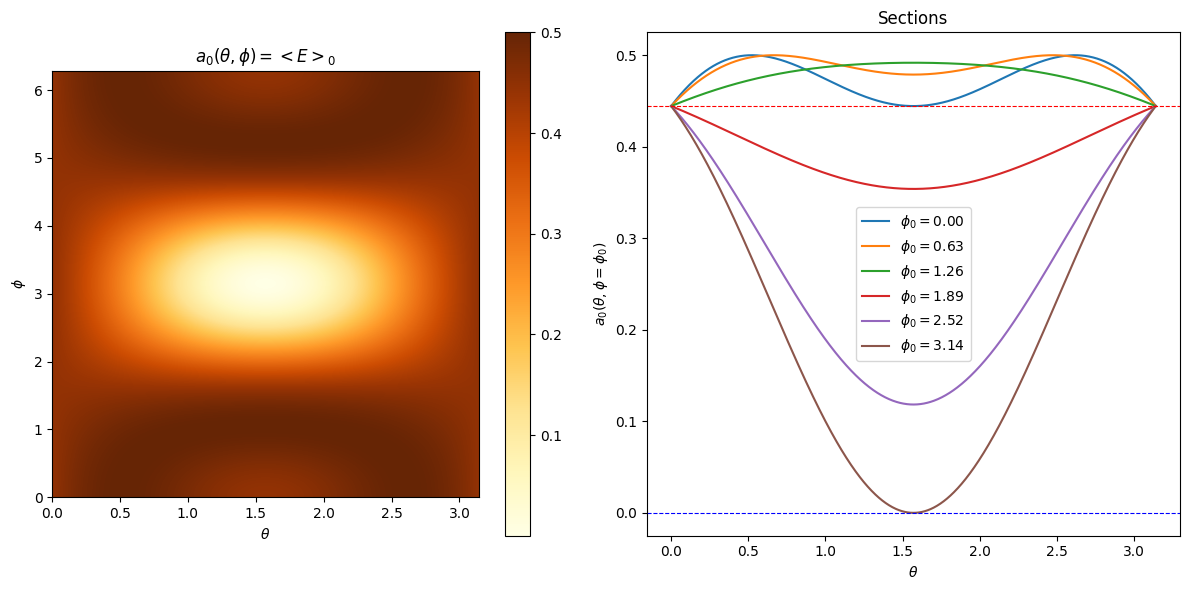

In [79]:
fig, axx = plt.subplots(1,2, figsize=(12,6), tight_layout=True)

Z = c_bars

im = axx[0].imshow(Z, extent=[thetas[0], thetas[-1], phis[0], phis[-1]], origin='lower', cmap='YlOrBr')
cbr = fig.colorbar(im, ax=axx[0])
axx[0].set_aspect(0.5)
axx[0].set_xlabel(r'$\theta$')
axx[0].set_ylabel(r'$\phi$')
axx[0].set_title(r'$a_0(\theta, \phi)= < E >_0$')

for i in range(6):
    axx[1].plot(thetas, c_bars[100*i,:], label=f"$\phi_0=${format(phis[100*i], '.2f')}")
axx[1].axhline(y=c_bars[0,0], linestyle='--', color='r', linewidth=0.8)
axx[1].axhline(y=0., linestyle='--', color='b', linewidth=0.8)
axx[1].set_xlabel(r'$\theta$')
axx[1].set_ylabel(r'$a_0(\theta, \phi=\phi_0)$')
axx[1].set_title(r'Sections')
axx[1].legend()

plt.show()

TO DO: fully characterize the triangle